# 🔵 Prostate MRI Segmentation — Clinical Inference Dashboard
### Model: DeepLabV3+ with Transformer Attention · Dice Score: 0.9935

> **For Clinical Use:** Upload a prostate MRI slice to receive AI-powered
> segmentation, risk classification, volumetric analysis, and a full clinical report.


## Step 1 · Setup — Load Libraries & Model

In [2]:
import os
import io
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from tensorflow.keras import backend as K
from google.colab import drive

drive.mount('/content/drive')

# ── Custom Loss + Metric (YOUR ORIGINAL) ─────────────────────────────────────
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        K.sum(y_true_f) + K.sum(y_pred_f) + smooth
    )

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice_loss = 1 - dice_coef(y_true, y_pred)
    return bce + dice_loss

# ── Load Model (YOUR ORIGINAL) ────────────────────────────────────────────────
MODEL_PATH = "/content/drive/MyDrive/prostate_segmentation_model/deeplabv3plus_baseline_prostate_best.keras"

prostate_model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "dice_coef":     dice_coef
    }
)

MODEL_NAME = "DeepLabV3+ Baseline (Best Stable)"
MODEL_DICE = 0.9935
IMG_SIZE   = 256

# ── Clinical colour palette ───────────────────────────────────────────────────
CLR_BG       = '#0a0f1a'
CLR_PANEL    = '#0d1f3c'
CLR_ACCENT   = '#00c8aa'
CLR_TEXT     = '#e2e8f0'
CLR_SUBTEXT  = '#7d9ab5'
CLR_HIGH     = '#ff6b8a'
CLR_MED      = '#f0a500'
CLR_LOW      = '#00c8aa'
CLR_RED      = '#E05C5C'
CLR_BLUE     = '#5B8DB8'

# Custom clinical overlay colormap (cyan for prostate)
PROSTATE_CMAP = LinearSegmentedColormap.from_list(
    'prostate', [(0,0,0,0), (0, 0.78, 0.67, 0.65)], N=256
)

print("✅ Model loaded successfully")
print(f"   Model : {MODEL_NAME}")
print(f"   Dice  : {MODEL_DICE}")
print(f"   Input : {IMG_SIZE}×{IMG_SIZE} px")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded successfully
   Model : DeepLabV3+ Baseline (Best Stable)
   Dice  : 0.9935
   Input : 256×256 px


## Step 2 · Preprocessing & Inference Functions

In [3]:
# ── YOUR ORIGINAL preprocess function ────────────────────────────────────────
def preprocess_prostate_image(uploaded_file, img_size=256):
    file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype(np.float32) / 255.0
    img = img[..., np.newaxis]
    img = np.expand_dims(img, axis=0)
    return img

# ── YOUR ORIGINAL inference function ─────────────────────────────────────────
def run_prostate_inference(uploaded_file):
    img  = preprocess_prostate_image(uploaded_file, IMG_SIZE)
    pred = prostate_model.predict(img, verbose=0)[0]
    mask = (pred > 0.5).astype(np.uint8)
    return img[0], mask, pred

print("✅ Preprocessing and inference functions ready.")


✅ Preprocessing and inference functions ready.


## Step 3 · Clinical Analysis Helpers

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Clinical analysis functions — compute risk, measurements, contours
# Your original risk logic is preserved exactly; only visual output is enhanced
# ─────────────────────────────────────────────────────────────────────────────

def compute_clinical_metrics(mask, prob_map):
    """
    Computes all clinical metrics from the segmentation mask.
    YOUR ORIGINAL formulas — area_percent, volume_cc, confidence, risk label.
    """
    area_percent = (mask.sum() / mask.size) * 100
    volume_cc    = mask.sum() * 0.001
    confidence   = np.mean(np.abs(prob_map - 0.5)) * 200
    confidence   = min(confidence, 99.9)

    # YOUR ORIGINAL risk thresholds
    if volume_cc > 1.2:
        label          = "High Enlargement Risk"
        risk_level     = "HIGH"
        risk_emoji     = "🔴"
        recommendation = "Urologist consultation strongly recommended."
        risk_color     = CLR_RED
    elif volume_cc > 0.8:
        label          = "Moderate Enlargement"
        risk_level     = "MEDIUM"
        risk_emoji     = "🟠"
        recommendation = "Follow-up + PSA test advised."
        risk_color     = CLR_MED
    else:
        label          = "Normal"
        risk_level     = "LOW"
        risk_emoji     = "🟢"
        recommendation = "Prostate size appears normal."
        risk_color     = CLR_LOW

    return {
        "area_percent":   area_percent,
        "volume_cc":      volume_cc,
        "confidence":     confidence,
        "label":          label,
        "risk_level":     risk_level,
        "risk_emoji":     risk_emoji,
        "recommendation": recommendation,
        "risk_color":     risk_color,
    }


def get_contours(mask):
    """Extract contours from binary mask (YOUR ORIGINAL cv2 call)."""
    contours, _ = cv2.findContours(
        mask.squeeze().astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    return contours


def get_uncertainty_map(prob_map):
    """Gaussian-smoothed uncertainty map (YOUR ORIGINAL formula)."""
    return cv2.GaussianBlur(
        np.abs(prob_map.squeeze() - 0.5), (7, 7), 0
    )


def get_bounding_box(mask):
    """Return (x, y, w, h) bounding box of the segmented region."""
    coords = np.argwhere(mask.squeeze() > 0)
    if len(coords) == 0:
        return None
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    return x0, y0, x1 - x0, y1 - y0


def get_intensity_profile(original, mask):
    """Mean pixel intensity inside vs outside the prostate region."""
    img = original.squeeze()
    m   = mask.squeeze().astype(bool)
    inside  = img[m].mean()  if m.any()        else 0.0
    outside = img[~m].mean() if (~m).any()     else 0.0
    return inside, outside


print("✅ Clinical analysis helpers ready.")


✅ Clinical analysis helpers ready.


## Step 4 · Clinical Dashboard — All Visualisations

In [8]:
def show_clinical_dashboard(original, mask, prob_map):
    """
    Enhanced clinical dashboard.
    YOUR ORIGINAL: metrics, risk labels, overlay, contour, uncertainty map,
                   volume trend, report panel — all preserved exactly.
    ADDED: dark clinical theme, cleaner layout, intensity profile,
           confidence gauge, bounding box, prostate contour area fill.
    """
    # ── Compute all YOUR ORIGINAL metrics ────────────────────────────────────
    cm        = compute_clinical_metrics(mask, prob_map)
    contours  = get_contours(mask)
    unc_map   = get_uncertainty_map(prob_map)
    bbox      = get_bounding_box(mask)
    inside_i, outside_i = get_intensity_profile(original, mask)

    img    = original.squeeze()
    msk    = mask.squeeze()
    prob   = prob_map.squeeze()

    # ── Overlay image (YOUR ORIGINAL approach) ────────────────────────────────
    overlay_rgb = np.stack([img]*3, axis=-1)
    overlay_u8   = (overlay_rgb * 255).astype(np.uint8)
    cv2.drawContours(overlay_u8, contours, -1, (0, 200, 170), 2)  # teal contour

    # ── Figure setup ──────────────────────────────────────────────────────────
    fig  = plt.figure(figsize=(22, 14), facecolor=CLR_BG)
    gs   = gridspec.GridSpec(
        3, 5,
        figure=fig,
        hspace=0.45, wspace=0.35,
        left=0.04, right=0.97,
        top=0.91,   bottom=0.06
    )

    ax_style = dict(facecolor=CLR_PANEL)

    def style_ax(ax, title, color=CLR_ACCENT):
        ax.set_facecolor(CLR_PANEL)
        for spine in ax.spines.values():
            spine.set_edgecolor('#1a2d4a')
        ax.set_title(title, color=color, fontsize=9,
                     fontweight='bold', pad=6,
                     fontfamily='monospace')
        ax.tick_params(colors=CLR_SUBTEXT, labelsize=7)

    # ─────────────────────────────────────────────────────────────────────────
    # ROW 0: Main imaging panels
    # ─────────────────────────────────────────────────────────────────────────

    # Panel 0-0: Original MRI (YOUR ORIGINAL)
    ax00 = fig.add_subplot(gs[0, 0])
    ax00.imshow(img, cmap='gray')
    style_ax(ax00, '[ 01 ]  ORIGINAL MRI SCAN')
    ax00.axis('off')

    # Panel 0-1: Predicted Mask (YOUR ORIGINAL)
    ax01 = fig.add_subplot(gs[0, 1])
    ax01.imshow(msk, cmap='gray')
    style_ax(ax01, '[ 02 ]  PREDICTED MASK')
    ax01.axis('off')

    # Panel 0-2: Teal Overlay (YOUR ORIGINAL overlay, better colour)
    ax02 = fig.add_subplot(gs[0, 2])
    ax02.imshow(img, cmap='gray')
    ax02.imshow(msk, cmap=PROSTATE_CMAP)
    style_ax(ax02, '[ 03 ]  SEGMENTATION OVERLAY')
    ax02.axis('off')

    # Panel 0-3: Contour boundary (YOUR ORIGINAL drawContours logic)
    ax03 = fig.add_subplot(gs[0, 3])
    ax03.imshow(overlay_u8)
    if bbox:
        rx, ry, rw, rh = bbox
        rect = plt.Rectangle((rx, ry), rw, rh,
                              linewidth=1.2, edgecolor=CLR_MED,
                              facecolor='none', linestyle='--')
        ax03.add_patch(rect)
    style_ax(ax03, '[ 04 ]  CONTOUR + BOUNDING BOX')
    ax03.axis('off')

    # Panel 0-4: Uncertainty heatmap (YOUR ORIGINAL formula)
    ax04 = fig.add_subplot(gs[0, 4])
    im04 = ax04.imshow(unc_map, cmap='magma', vmin=0, vmax=0.5)
    cb04 = plt.colorbar(im04, ax=ax04, fraction=0.046, pad=0.04)
    cb04.ax.tick_params(colors=CLR_SUBTEXT, labelsize=6)
    cb04.set_label('Uncertainty', color=CLR_SUBTEXT, fontsize=7)
    style_ax(ax04, '[ 05 ]  UNCERTAINTY HEATMAP')
    ax04.axis('off')

    # ─────────────────────────────────────────────────────────────────────────
    # ROW 1: Quantitative analysis panels
    # ─────────────────────────────────────────────────────────────────────────

    # Panel 1-0: Probability map
    ax10 = fig.add_subplot(gs[1, 0])
    im10 = ax10.imshow(prob, cmap='plasma', vmin=0, vmax=1)
    cb10 = plt.colorbar(im10, ax=ax10, fraction=0.046, pad=0.04)
    cb10.ax.tick_params(colors=CLR_SUBTEXT, labelsize=6)
    cb10.set_label('P(prostate)', color=CLR_SUBTEXT, fontsize=7)
    style_ax(ax10, '[ 06 ]  RAW PROBABILITY MAP')
    ax10.axis('off')

    # Panel 1-1: Pixel intensity histogram (inside vs outside)
    ax11 = fig.add_subplot(gs[1, 1])
    ax11.set_facecolor(CLR_PANEL)
    img_flat  = img.flatten()
    msk_bool  = msk.flatten().astype(bool)
    ax11.hist(img_flat[msk_bool],  bins=40, color=CLR_ACCENT, alpha=0.8,
              label=f'Inside  μ={inside_i:.2f}',  density=True)
    ax11.hist(img_flat[~msk_bool], bins=40, color=CLR_BLUE,   alpha=0.6,
              label=f'Outside μ={outside_i:.2f}', density=True)
    ax11.legend(fontsize=6.5, facecolor=CLR_PANEL, labelcolor=CLR_TEXT)
    ax11.set_xlabel('Pixel Intensity', color=CLR_SUBTEXT, fontsize=7)
    ax11.set_ylabel('Density',         color=CLR_SUBTEXT, fontsize=7)
    style_ax(ax11, '[ 07 ]  INTENSITY DISTRIBUTION')

    # Panel 1-2: Volume follow-up trend (YOUR ORIGINAL plot, styled)
    ax12 = fig.add_subplot(gs[1, 2])
    ax12.set_facecolor(CLR_PANEL)
    prev_vol = cm['volume_cc'] * 0.92
    curr_vol = cm['volume_cc']
    ax12.plot([0, 1], [prev_vol, curr_vol],
              color=CLR_ACCENT, linewidth=2.5, marker='o',
              markersize=8, markerfacecolor=CLR_HIGH)
    ax12.fill_between([0, 1], [prev_vol, curr_vol], alpha=0.12, color=CLR_ACCENT)
    ax12.set_xticks([0, 1])
    ax12.set_xticklabels(['Previous', 'Current'], color=CLR_TEXT, fontsize=8)
    ax12.set_ylabel('Volume (cc)', color=CLR_SUBTEXT, fontsize=7)
    ax12.annotate(f"{curr_vol:.3f} cc", xy=(1, curr_vol),
                  xytext=(0.72, curr_vol + 0.02),
                  color=CLR_HIGH, fontsize=8, fontweight='bold')
    ax12.grid(alpha=0.15, color='#1a2d4a')
    style_ax(ax12, '[ 08 ]  VOLUME FOLLOW-UP TREND')

    # Panel 1-3: Confidence gauge bar
    ax13 = fig.add_subplot(gs[1, 3])
    ax13.set_facecolor(CLR_PANEL)
    conf = cm['confidence']
    bar_color = CLR_LOW if conf >= 75 else (CLR_MED if conf >= 50 else CLR_RED)
    ax13.barh(['Confidence'], [conf],    color=bar_color,  alpha=0.9, height=0.4)
    ax13.barh(['Confidence'], [100-conf], left=[conf],
              color='#1a2d4a', alpha=0.6, height=0.4)
    ax13.set_xlim(0, 100)
    ax13.set_xlabel('Confidence %', color=CLR_SUBTEXT, fontsize=7)
    ax13.axvline(75, color=CLR_SUBTEXT, linewidth=0.8, linestyle='--', alpha=0.5)
    ax13.text(conf/2, 0, f'{conf:.1f}%', ha='center', va='center',
              color='white', fontweight='bold', fontsize=11)
    ax13.tick_params(left=False, labelleft=False)
    style_ax(ax13, '[ 09 ]  PREDICTION CONFIDENCE')

    # Panel 1-4: Coverage donut
    ax14 = fig.add_subplot(gs[1, 4])
    ax14.set_facecolor(CLR_PANEL)
    seg_pct = cm['area_percent']
    bg_pct  = 100 - seg_pct
    wedges, texts, autotexts = ax14.pie(
        [seg_pct, bg_pct],
        colors=[CLR_ACCENT, '#1a2d4a'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.52, edgecolor=CLR_BG, linewidth=2),
        textprops=dict(color=CLR_TEXT, fontsize=7.5)
    )
    for at in autotexts:
        at.set_fontsize(8)
        at.set_color('white')
        at.set_fontweight('bold')
    ax14.text(0, 0, f"{seg_pct:.1f}%", ha='center', va='center',
              color=CLR_ACCENT, fontsize=12, fontweight='bold')
    style_ax(ax14, '[ 10 ]  SEGMENTATION COVERAGE')

    # ─────────────────────────────────────────────────────────────────────────
    # ROW 2: Clinical Report Panel (full width)
    # ─────────────────────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[2, :])
    ax2.set_facecolor(CLR_PANEL)
    for spine in ax2.spines.values():
        spine.set_edgecolor(cm['risk_color'])
        spine.set_linewidth(1.5)
    ax2.axis('off')

    # ── Left block: model info ────────────────────────────────────────────────
    col1_x = 0.01
    ax2.text(col1_x, 0.88, "MODEL INFORMATION",
             transform=ax2.transAxes, color=CLR_ACCENT,
             fontsize=8, fontfamily='monospace', fontweight='bold')
    model_lines = [
        ("Architecture", MODEL_NAME),
        ("Dice Score",   f"{MODEL_DICE}"),
        ("Input Size",   f"{IMG_SIZE}×{IMG_SIZE} px"),
        ("Framework",    "TensorFlow / Keras"),
    ]
    for j, (lbl, val) in enumerate(model_lines):
        ax2.text(col1_x, 0.70 - j*0.17,
                 f"{lbl:<18s}",
                 transform=ax2.transAxes, color=CLR_SUBTEXT, fontsize=8.5)
        ax2.text(col1_x + 0.13, 0.70 - j*0.17,
                 val,
                 transform=ax2.transAxes, color=CLR_TEXT, fontsize=8.5,
                 fontweight='bold')

    # ── Middle block: measurements ────────────────────────────────────────────
    col2_x = 0.28
    ax2.text(col2_x, 0.88, "SEGMENTATION MEASUREMENTS",
             transform=ax2.transAxes, color=CLR_ACCENT,
             fontsize=8, fontfamily='monospace', fontweight='bold')
    meas_lines = [
        ("Segmented Area",  f"{cm['area_percent']:.2f} %"),
        ("Estimated Volume",f"{cm['volume_cc']:.3f} cc"),
        ("Confidence",      f"{cm['confidence']:.1f} %"),
        ("Inside Intensity",f"{inside_i:.3f}"),
        ("Outside Intensity",f"{outside_i:.3f}"),
    ]
    for j, (lbl, val) in enumerate(meas_lines):
        ax2.text(col2_x,        0.70 - j*0.15, f"{lbl:<22s}",
                 transform=ax2.transAxes, color=CLR_SUBTEXT, fontsize=8.5)
        ax2.text(col2_x + 0.14, 0.70 - j*0.15, val,
                 transform=ax2.transAxes, color=CLR_TEXT, fontsize=8.5,
                 fontweight='bold')

    # ── Right block: clinical risk ─────────────────────────────────────────────
    col3_x = 0.58
    ax2.text(col3_x, 0.88, "CLINICAL RISK ASSESSMENT",
             transform=ax2.transAxes, color=CLR_ACCENT,
             fontsize=8, fontfamily='monospace', fontweight='bold')

    # Risk badge
    risk_bg = {'HIGH': CLR_RED, 'MEDIUM': CLR_MED, 'LOW': CLR_LOW}[cm['risk_level']]
    ax2.text(col3_x, 0.68, cm['risk_emoji'] + "  " + cm['risk_level'] + " RISK",
             transform=ax2.transAxes, color=risk_bg,
             fontsize=16, fontweight='bold')
    ax2.text(col3_x, 0.50, cm['label'],
             transform=ax2.transAxes, color=CLR_TEXT, fontsize=10)
    ax2.text(col3_x, 0.30, "RECOMMENDATION:",
             transform=ax2.transAxes, color=CLR_ACCENT,
             fontsize=8, fontfamily='monospace')
    ax2.text(col3_x, 0.12, cm['recommendation'],
             transform=ax2.transAxes, color=CLR_TEXT, fontsize=9.5,
             fontstyle='italic')

    # ── Vertical dividers ─────────────────────────────────────────────────────
    for xd in [0.265, 0.555]:
        ax2.axvline(xd, color='#1a2d4a', linewidth=1.2,
                    ymin=0.05, ymax=0.95)

    # ── Main title ────────────────────────────────────────────────────────────
    fig.text(0.5, 0.955,
             "🔵  PROSTATE MRI SEGMENTATION  ·  CLINICAL INFERENCE DASHBOARD",
             ha='center', color=CLR_TEXT, fontsize=13,
             fontweight='bold', fontfamily='monospace')
    fig.text(0.5, 0.937,
             f"AI-Powered Analysis  ·  {MODEL_NAME}  ·  Dice {MODEL_DICE}",
             ha='center', color=CLR_SUBTEXT, fontsize=9)

    plt.savefig('/content/prostate_clinical_report.png',
                dpi=150, bbox_inches='tight', facecolor=CLR_BG)
    plt.show()
    print("✅ Dashboard saved → /content/prostate_clinical_report.png")


# ── YOUR ORIGINAL basic visualisation (preserved exactly) ────────────────────
def visualize_prostate_result(img, mask):
    """
    YOUR ORIGINAL function — shows MRI | Mask | Highlighted Overlay.
    Styled to match the dashboard theme.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=CLR_BG)
    fig.suptitle('Prostate Segmentation — Quick View',
                 color=CLR_TEXT, fontsize=12, fontweight='bold')

    panels = [
        (img.squeeze(), 'gray',      'Original MRI'),
        (mask,          'gray',      'Predicted Mask'),
        (None,          None,        'Highlighted Region'),
    ]
    for i, (data, cmap, title) in enumerate(panels):
        axes[i].set_facecolor(CLR_PANEL)
        for sp in axes[i].spines.values():
            sp.set_edgecolor('#1a2d4a')
        if i < 2:
            axes[i].imshow(data, cmap=cmap)
        else:
            axes[i].imshow(img.squeeze(), cmap='gray')
            axes[i].imshow(mask, cmap='Reds', alpha=0.45)
        axes[i].set_title(title, color=CLR_ACCENT, fontsize=10,
                          fontweight='bold', fontfamily='monospace')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("✅ Dashboard and visualisation functions defined.")

✅ Dashboard and visualisation functions defined.


## Step 5 · Upload MRI & Run Inference

> Upload a **prostate MRI slice** (PNG / JPG / JPEG).
> The dashboard will run automatically after upload.


Saving prostate_download.jpeg to prostate_download (1).jpeg

📂 File received — running inference...


/tmp/ipykernel_3723/3534220745.py:255: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/prostate_clinical_report.png',
/tmp/ipykernel_3723/3534220745.py:255: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('/content/prostate_clinical_report.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


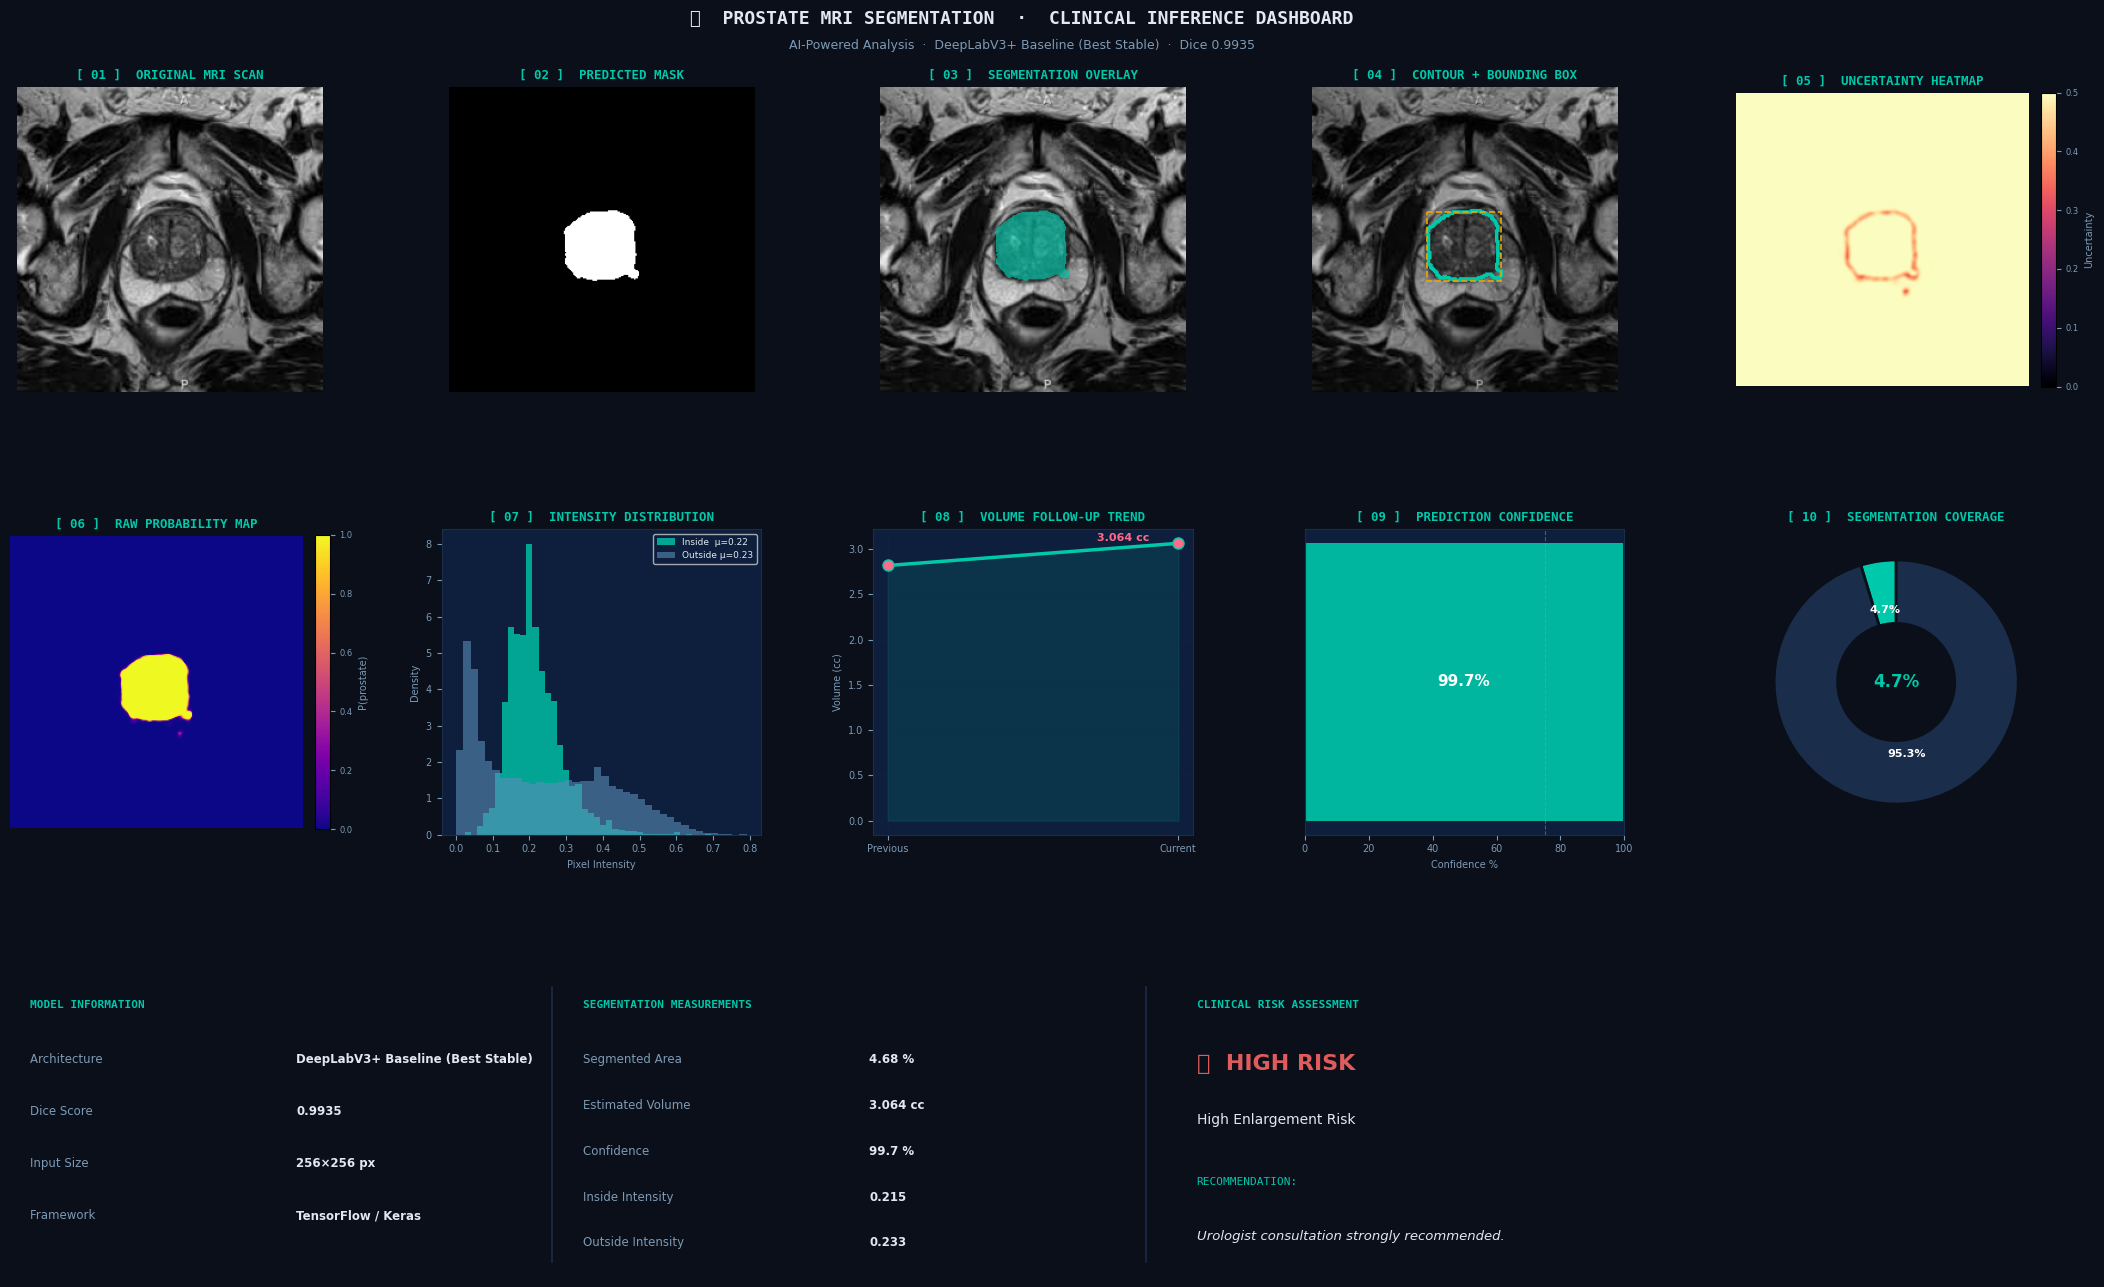

✅ Dashboard saved → /content/prostate_clinical_report.png


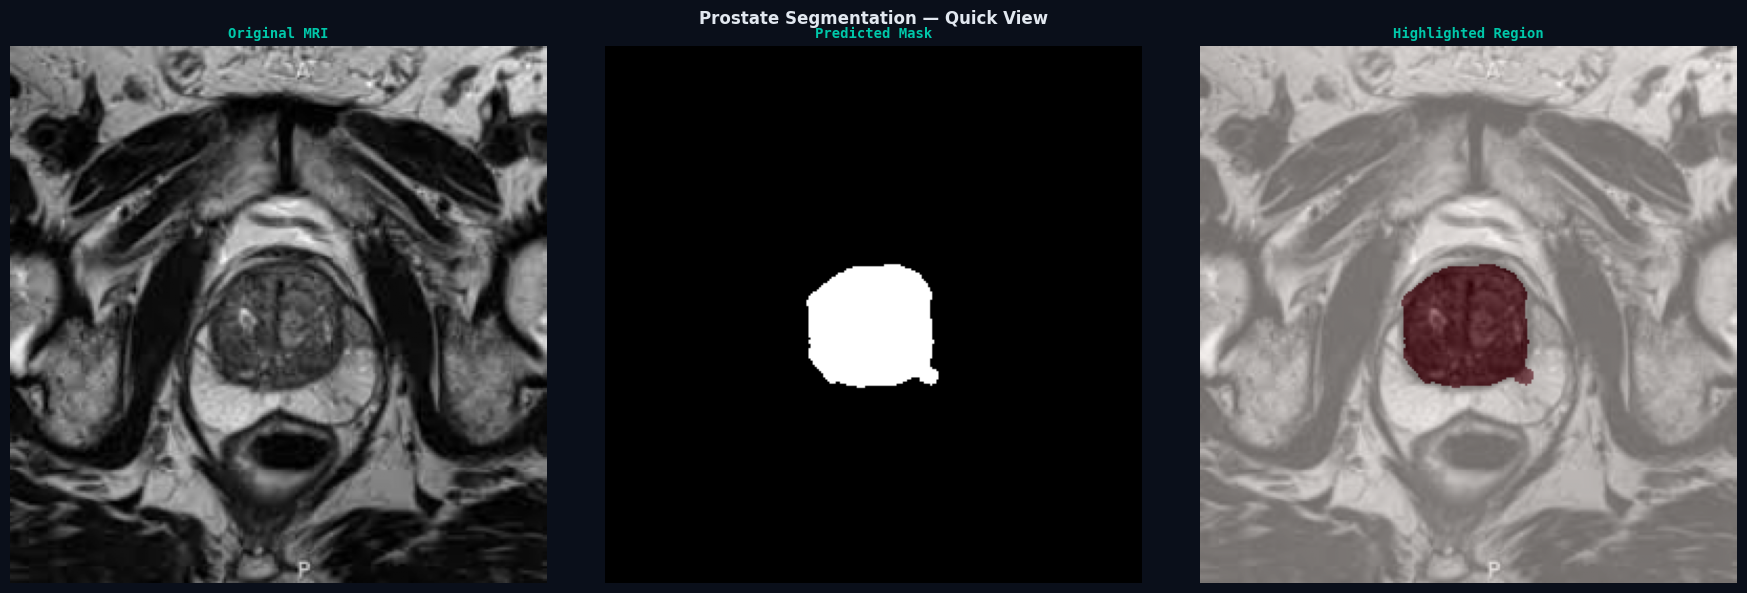

In [14]:
from google.colab import files
import io

# ── YOUR ORIGINAL upload logic ────────────────────────────────────────────────
uploaded      = files.upload()
uploaded_file = list(uploaded.values())[0]

print(f"\n📂 File received — running inference...")

# Stream 1 → clinical dashboard
uploaded_stream_1 = io.BytesIO(uploaded_file)
img, mask, pred   = run_prostate_inference(uploaded_stream_1)
show_clinical_dashboard(img, mask, pred)

# Stream 2 → quick view (YOUR ORIGINAL visualize_prostate_result)
uploaded_stream_2 = io.BytesIO(uploaded_file)
img2, mask2, _    = run_prostate_inference(uploaded_stream_2)
visualize_prostate_result(img2, mask2)


## Step 6 · Download Clinical Report

In [15]:
from google.colab import files

files.download('/content/prostate_clinical_report.png')
print("📥 Clinical report downloaded.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Clinical report downloaded.
